In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

The dataset contains 48895 listings and 16 features.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

The variables last_review and reviews_per_month contain a substantial number of missing values, likely corresponding to listings without reviews.

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


The mean is substantially higher than the median, indicating a right-skewed distribution.
This suggests the presence of high-price outliers that pull the mean upward.
The extremely high maximum price (10000) likely represents an outlier and may distort further analysis.
Therefore, it is necessary to visualize the distribution and potentially treat extreme values.

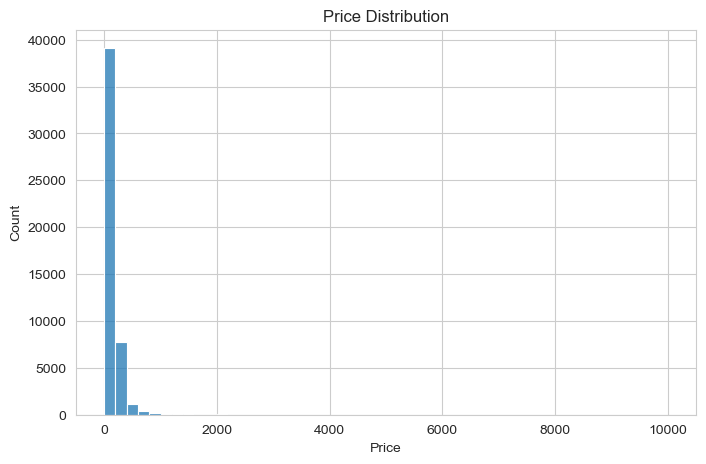

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The histogram shows a highly right-skewed distribution.
Most listings are concentrated at the lower end of the price range, while a small number of extremely expensive lsitings extend up to 10000 USD.
These extreme values stretch the x-axis and compress the majority of the distribution, making it difficult to interpret the typical pricing structure.
This confirms the presence of strong outliers, which significantly distort the visualization.

In [7]:
p99 = df["price"].quantile(0.99)
p99

np.float64(799.0)

The 99th percentile of the price distribution is approximately 799 USD.
This means that 99% of all listings are priced at or below 799 USD, while only 1% exceed this threshold.
Listings above this value represent extreme luxury cases and may disproportionately influence summary statistics and visualizations.
Therefore, prices above the 99th percentile will be excluded to focus the analysis on the typical market segment.

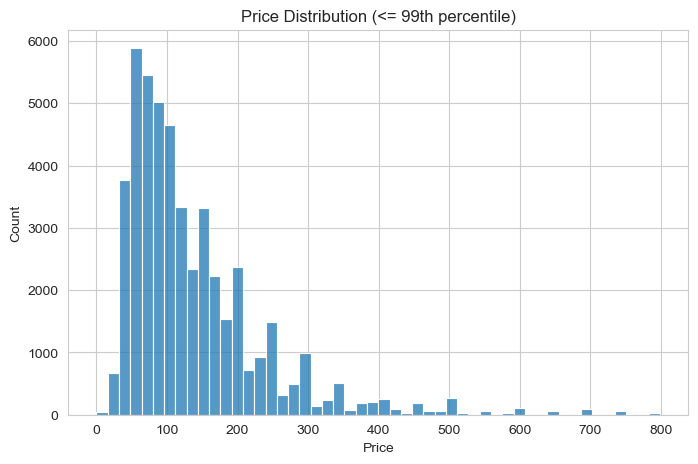

In [8]:
df_filtered = df[df["price"] <= p99]

plt.figure(figsize=(8,5))
sns.histplot(df_filtered["price"], bins=50)
plt.title("Price Distribution (<= 99th percentile)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

After excluding prices above the 99th percentile (799 USD), the distribution becomes significantly more interpretable.
The majority of listings are concentrated below approximately 200 USD, with a clear decline in frequency as prices increase.
The distribution remains right-skewed, but the influence of extreme luxury listings has been substantially reduced.
This filtered view provides a more realistic representation of the typical Airbnb market structure in NYC.

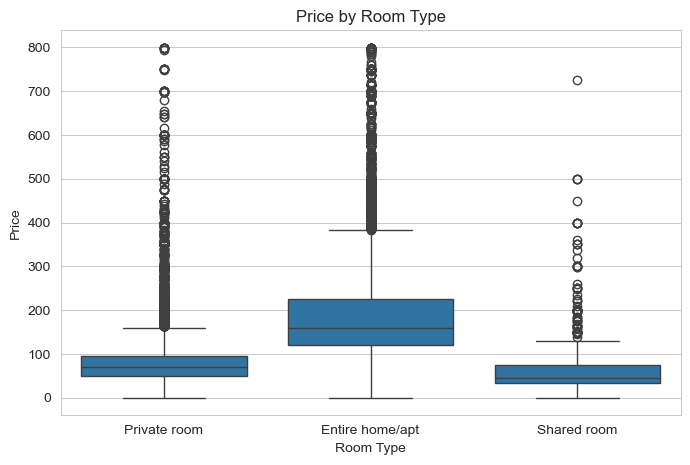

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_filtered, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

The boxplot reveals price differences across different room types.
Entire home/apartment listings exhibit the highest median price and the largest variability, indicating that full-property rentals command a significant premium.
Private rooms are moderately priced, reflecting a balance between affordability and privacy.
Shared rooms represent the most bduget-friendly option, with the lowest median prices and comparatively limited dispersion.
These findings suggest that room type is a strong determinant of pricing and should be considered a key explanatory variable in further analysis.


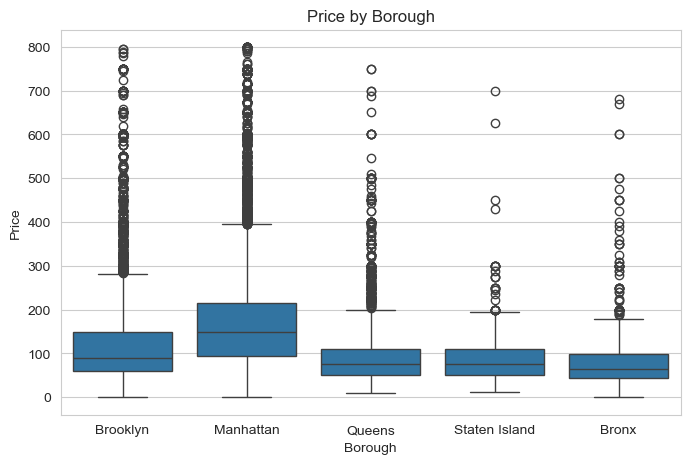

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_filtered, x="neighbourhood_group", y="price")
plt.title("Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Price")
plt.show()

The boxplot demonstrates clear location-based pricing differences across NYC boroughs.
Manhattan exhibits the highest median price and the largest variability, confirming  its premium status as the economic and touristic center of the city.
Brooklyn follows as the second most expensive borough, reflecting its popularity and ongoing urban development.
Queens, Staten Island and the Bronx show significantly lower median prices, indicating more affordable market segments.
These findings highlight location as one of the strongest determinants of Airbnb pricing.

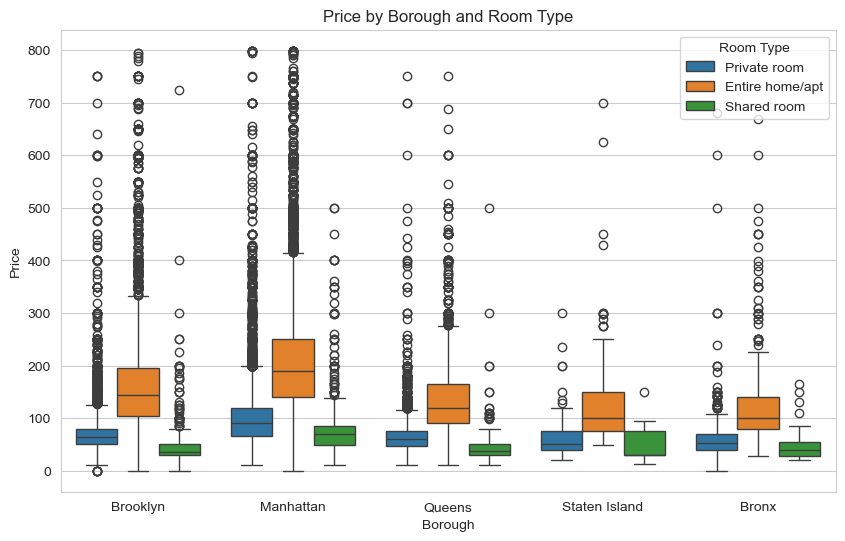

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_filtered, x="neighbourhood_group", y="price", hue="room_type")
plt.title("Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Price")
plt.legend(title="Room Type")
plt.show()

The combined boxplot reveals a strong interaction between location and room type.
Entire home/apartment lsitings in Manhattan represent the highest priced segment of the market, significantly exceeding prices in all other boroughs.
This indicates a premium market driven by both location and full-property rental.
Private rooms follow a similar pattern, although price differences across boroughs are less extreme compared to entire homes.
Shared rooma remain the most affordable option across all boroughs, with relatively smaller location-based price variations.
These findings suggest that both lcoation and accommodation type jointly determine Airbnb pricing, with Manhattan entire homes forming the premium core of the NYC market.

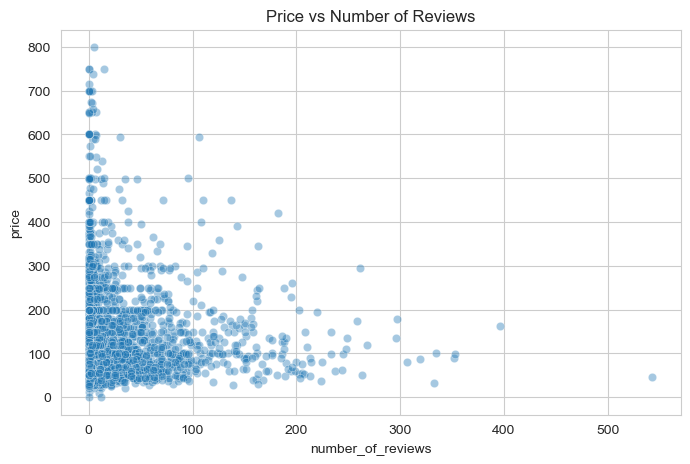

np.float64(-0.05560938754177823)

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_filtered.sample(3000, random_state=42),
    x="number_of_reviews",
    y="price",
    alpha=0.4
)
plt.title("Price vs Number of Reviews")
plt.show()

df_filtered["price"].corr(df_filtered["number_of_reviews"])

The pearson correlation coefficient between price and number_of_reviews is approximately -0.056 indicating an extremely weak negative linear relationship.
This confirms the visual impression from the scatterplot: review frequency does not meaningfully predict price levels.
If anything, listings with higher review counts tend to be slighlty more affordable, possibly reflecting higher booking frequency for competitively priced properties.
Thus, popularity (measured by review count) appears largely independent of pricing.

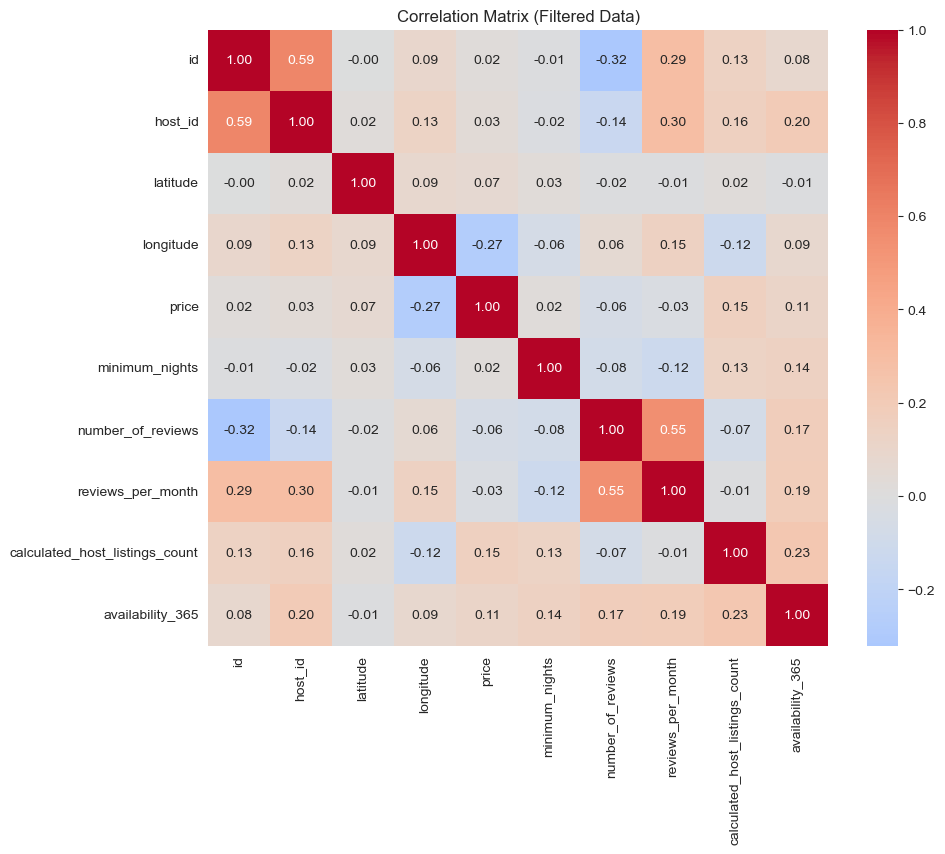

In [14]:
numeric_df = df_filtered.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            center=0)

plt.title("Correlation Matrix (Filtered Data)")
plt.show()

The correlation matrix reveals generally weak linear relationships between price and other numerical variables.
The strongest correlation with price is observed for longitude (-0.27), suggesting a modest spatial pricing effect.
However, no numerical variable exhibits a strong linear association with price.
A notable positive correlation exists between number_of_reviews and reviews_per_month (0.55), which is expected as both variables measure listing popularity.
Overall, these findings suggest that Airbnb pricing in NYC is not strongly driven by simple numerical metrics.
Instead, categorial factors such as borough and room type appear to play a more significant role.

# Executive Summary
This exploratory data analysis examined Airbnb listings in New York City to understand the main factors influencing pricing.

The initial distribution of prices was hihgly right-skewed, with extreme outliers reaching up to 10000 USD.
After removing values above the 99th percentile (799 USD), the distribution became more interpretable while retaining the overall structure of the market.

Room type and borough emerged as the strongest determinants of price. Entire home/apartment listings are significantly more expensive than private or shared rooms, and Manhattan consistently shows the highest median prices across all accommodations types.
This confirms the strong influence of both location and accommodation type on pricing.

In contrast, numerical variables such as number_of_reviews, minimum_nights and availability show only weak linear relationships with price.
The correlation analysis indicates that price is not strongly driven by individual numerical features but rather by categorial characteristics.

Overall, Airbnb pricing in NYC appears to be primarly structured around location and property type, with demand related metrics playing a secondary role.